In [ ]:
#Necessary libraries for Data Exploration
import pandas as pd #Object name
import seaborn as sns #Advanced Visualization
import matplotlib.pyplot as plt #Visualization

In [ ]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
url = "https://raw.githubusercontent.com/vega/vega-datasets/master/data/seattle-weather.csv"
df=pd.read_csv(url)

In [ ]:
df.head() #First 5 rows of the dataset

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
#5 vs - Volume, Velocity, Variety, Veracity, Value.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
df['date']=pd.to_datetime(df['date']) #to_datetime- ISO- YYYY-MM-DD
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 68.6+ KB


In [ ]:
df['date'].max()

Timestamp('2015-12-31 00:00:00')

In [ ]:
#df['date']=df['date'].dt.strftime('%d-%m-%Y')


In [ ]:
df['date'].dt.day

,date
0,1
1,2
2,3
3,4
4,5
...,...
1456,27
1457,28
1458,29
1459,30


In [ ]:
df.to_excel('weather.xlsx')

In [ ]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


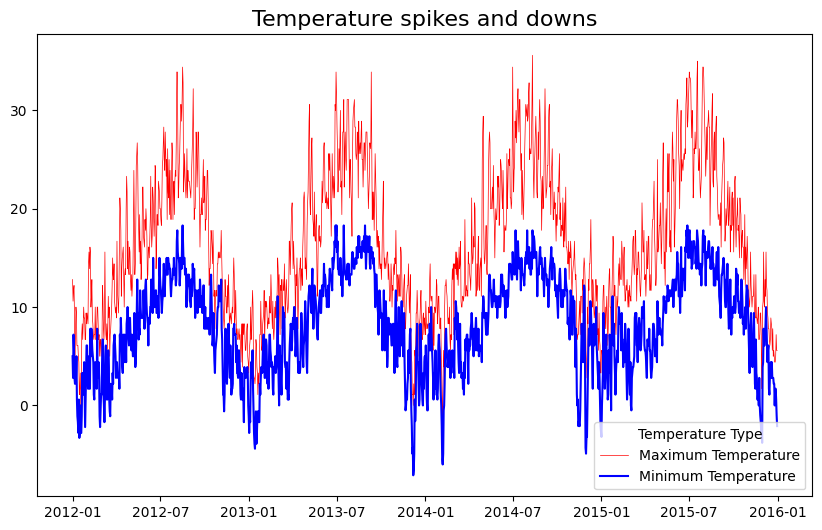

In [ ]:
#Basic EDA Visualization
#Frequency - x axis- Univariate Analysis
#x-axis, y-axis- bivariate analysis
#x-axis- date, y-axis - temp_max

plt.figure(figsize=(10,6))
plt.plot(df['date'], df['temp_max'], color='red', label='Maximum Temperature', linewidth=0.5)
plt.plot(df['date'], df['temp_min'], color='blue', label='Minimum Temperature')
plt.title('Temperature spikes and downs', fontsize=16)
plt.legend(title='Temperature Type')
plt.show()


In [ ]:
#Missing Values
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


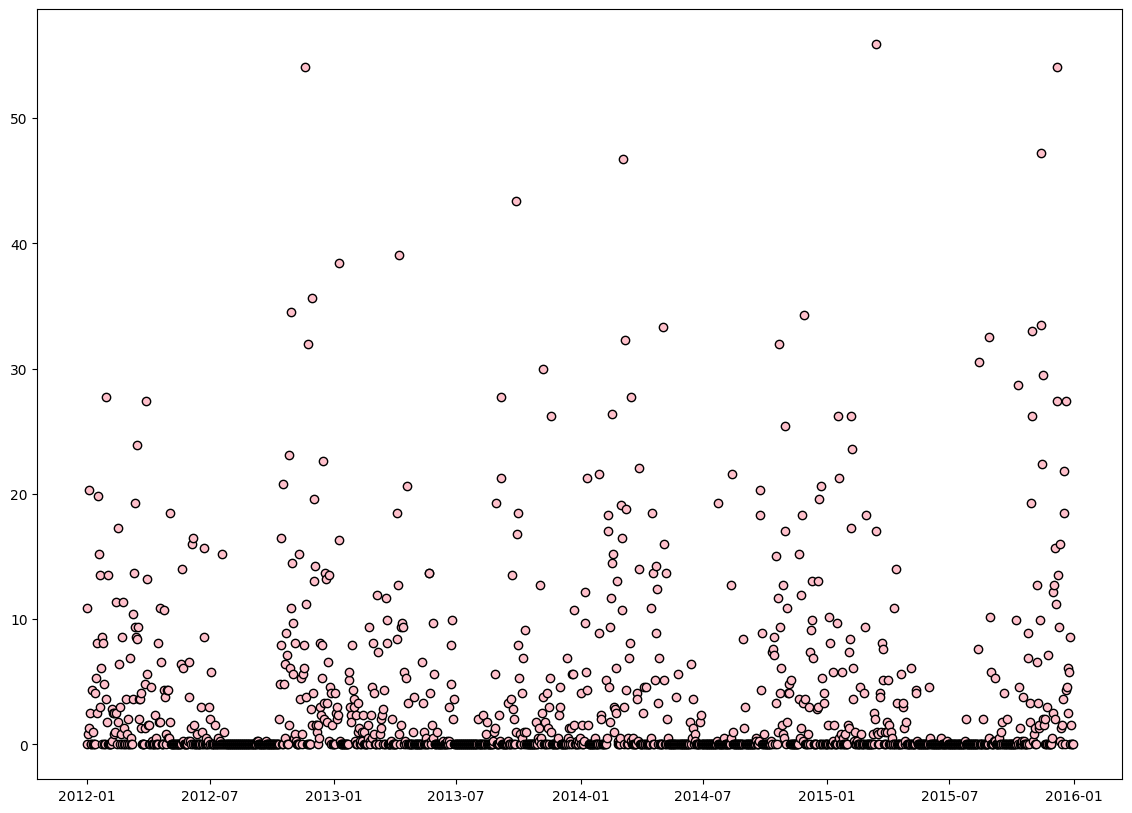

In [ ]:
#Daily Precipitation Plotting.
plt.figure(figsize=(14,10))
plt.scatter(df['date'],df['precipitation'], color='pink', edgecolor='black')
plt.show()

/tmp/ipython-input-4161673127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=df, palette='viridis') #palette= viridis, cool, set2, pastel, coolwarm, Reds, Blues


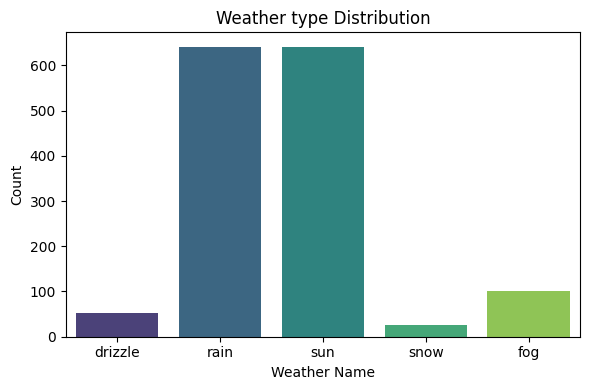

In [ ]:
#Weather type Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='weather', data=df, palette='viridis') #palette= viridis, cool, set2, pastel, coolwarm, Reds, Blues
plt.xlabel('Weather Name')
plt.ylabel('Count')
plt.title("Weather type Distribution")
plt.tight_layout()
plt.show()

In [ ]:
#Creating monthly summary for the values
monthly_summary=df.groupby(df['date'].dt.month).agg({
    'temp_max':'mean',
    'temp_min':'mean',
    'precipitation':'sum'
}).reset_index()

In [ ]:
monthly_summary

,date,temp_max,temp_min,precipitation
0,1,8.229032,2.696774,466.0
1,2,9.860177,4.054867,422.0
2,3,12.387097,4.858871,606.2
3,4,15.020000,6.362500,375.4
4,5,19.295968,9.614516,207.5
5,6,22.400000,12.244167,132.9
6,7,25.998387,14.197581,48.2
7,8,26.112097,14.769355,163.7
8,9,21.924167,12.358333,235.5
9,10,16.389516,9.350806,503.4


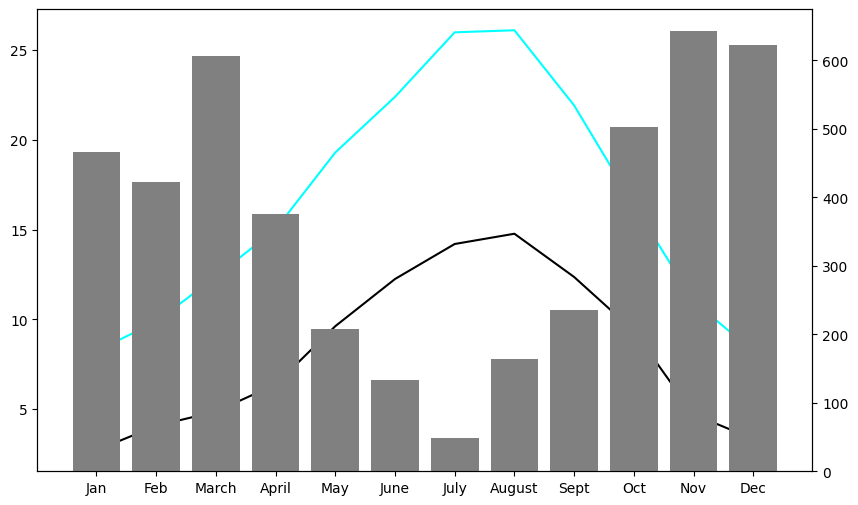

In [ ]:
fig, ax1= plt.subplots(figsize=(10,6))

#Temperature lines- Axis 1
ax1.plot(monthly_summary['date'], monthly_summary['temp_max'], label='Avg Max Temperature', color='cyan')
ax1.plot(monthly_summary['date'], monthly_summary['temp_min'], label='Avg Min Temperature', color='black')
ax1.set_xticks(monthly_summary['date'])
ax1.set_xticklabels(['Jan','Feb','March','April','May', 'June','July','August','Sept','Oct','Nov','Dec'])

#Second Axis for Precipitation
ax2=ax1.twinx()
ax2.bar(monthly_summary['date'], monthly_summary['precipitation'], color='gray', label='Total Precipitation')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 68.6+ KB


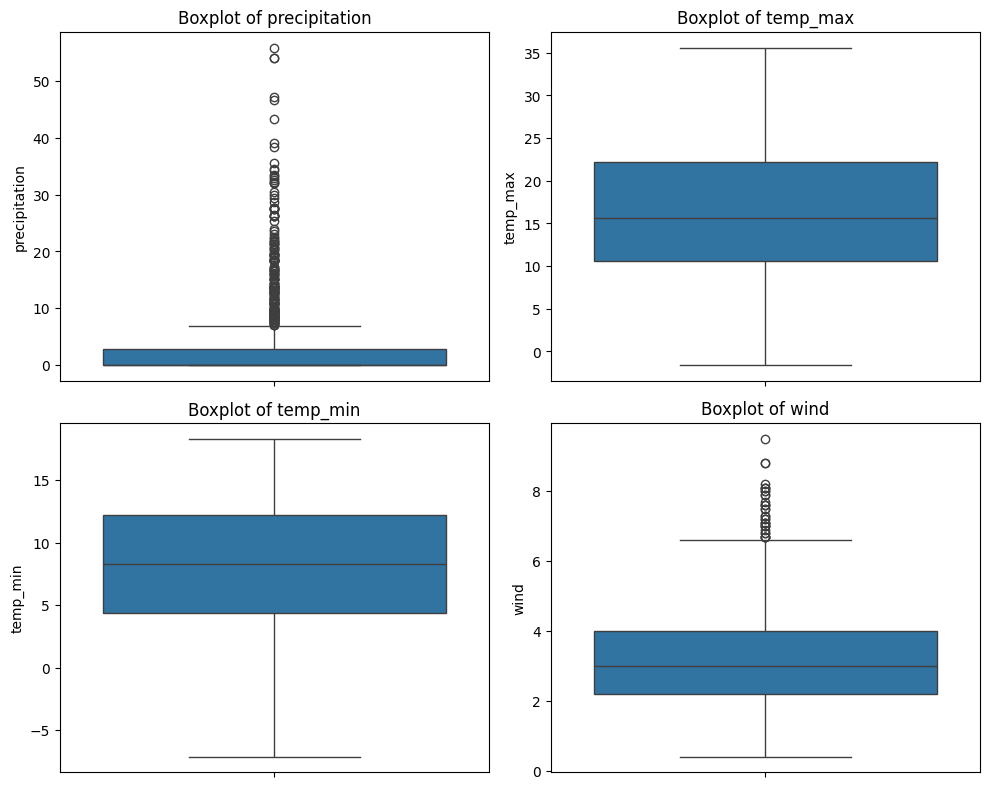

In [ ]:
# Creating boxplots for numerical columns to visualize outliers
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
#use exclude to remove all numerical columns.

plt.figure(figsize=(10,8))   #white canvas
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
#Function to identify and drop outliers using IQR
def drop_outliers_iqr(df, columns):
    for col in columns: #Q1, Q3, IQR.
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

        print(f"Number of outliers in '{col}':", len(outliers))

        # Drop outliers
        df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]
    return df

# Select numerical columns for outlier detection (excluding 'date')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Apply the function to drop outliers
df_cleaned = drop_outliers_iqr(df.copy(), numerical_cols)

print("\nShape of the original DataFrame:", df.shape)
print("Shape of the DataFrame after dropping outliers:", df_cleaned.shape)

Number of outliers in 'precipitation': 206
Number of outliers in 'temp_max': 0
Number of outliers in 'temp_min': 0
Number of outliers in 'wind': 44

Shape of the original DataFrame: (1461, 6)
Shape of the DataFrame after dropping outliers: (1211, 6)


In [ ]:
df_cleaned

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
2,2012-01-03,0.8,11.7,7.2,2.3,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
5,2012-01-06,2.5,4.4,2.2,2.2,rain
6,2012-01-07,0.0,7.2,2.8,2.3,rain
...,...,...,...,...,...,...
1455,2015-12-26,0.0,4.4,0.0,2.5,sun
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [ ]:
df_cleaned.to_excel('cleaned_seattle_weather.xlsx')